In [1]:
import numpy as np
import matplotlib.pyplot as plt
from diag_operator_build_wf import *
import matplotlib.colors as colours

plt.rcParams["text.usetex"] = True
plt.rcParams["figure.dpi"] = 150

In [25]:
N = 1009 # dimensions of Hilbert space
alpha = 0
beta = 0
K = 0.1 # kicking strength

U = diagonalize_floquet_operator(N, alpha, beta, K)

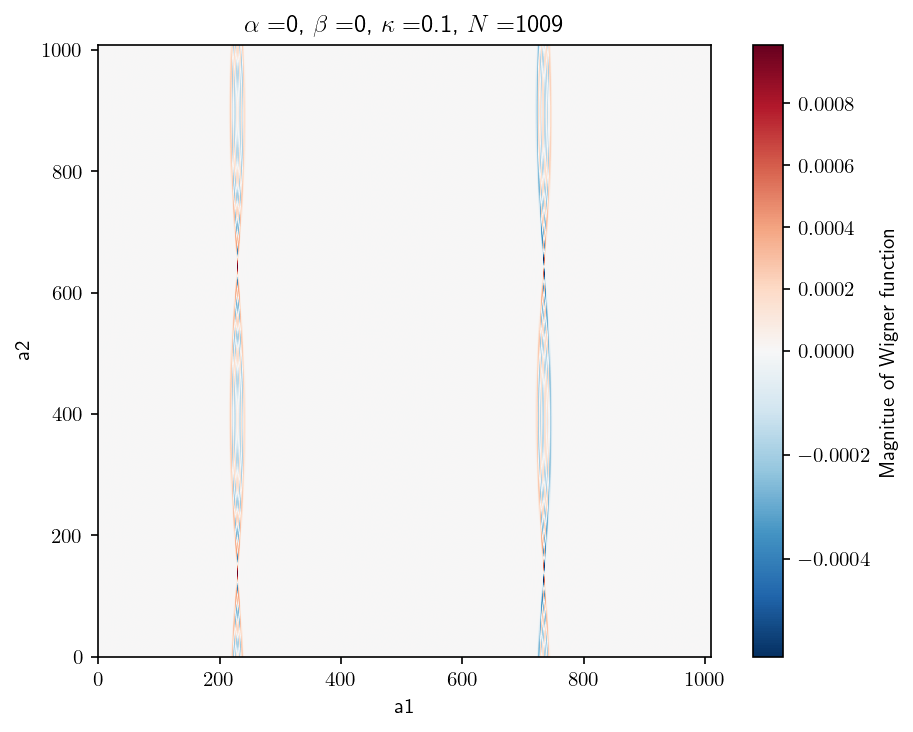

In [26]:
# find the eigenvalues and eigenvectors of the floquet operator

eigvals, eigvecs = np.linalg.eig(U)

n = N-1 # choose a random eigenvector of the floquet operator to compute the wigner function of

W_floquet_eigvec = wigner_function(eigvecs[:, n])

# include a check to see if wigner function is computed correctly

if np.isclose(np.sum(W_floquet_eigvec), 1):
    # plot the wigner function

    vmin = np.min(W_floquet_eigvec)
    vmax = np.max(W_floquet_eigvec)

    norm = colours.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

    plt.imshow(W_floquet_eigvec, cmap='RdBu_r', origin='lower', norm = norm,interpolation='nearest')
    plt.colorbar(label='Magnitue of Wigner function')
    plt.xlabel('a1')
    plt.ylabel('a2')
    plt.tight_layout()
    plt.title(r"$\alpha =$"+f"{alpha}, "+r"$\beta =$"+f"{beta}, "+r"$\kappa =$"+f"{K}, "+r"$N =$"+f"{N}")
    plt.show()

else:
    print("Wigner function has not been computed properly")

/var/folders/c8/m11vsrv50cv5c2b0ljtrkgtw0000gn/T/ipykernel_63924/3584001226.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


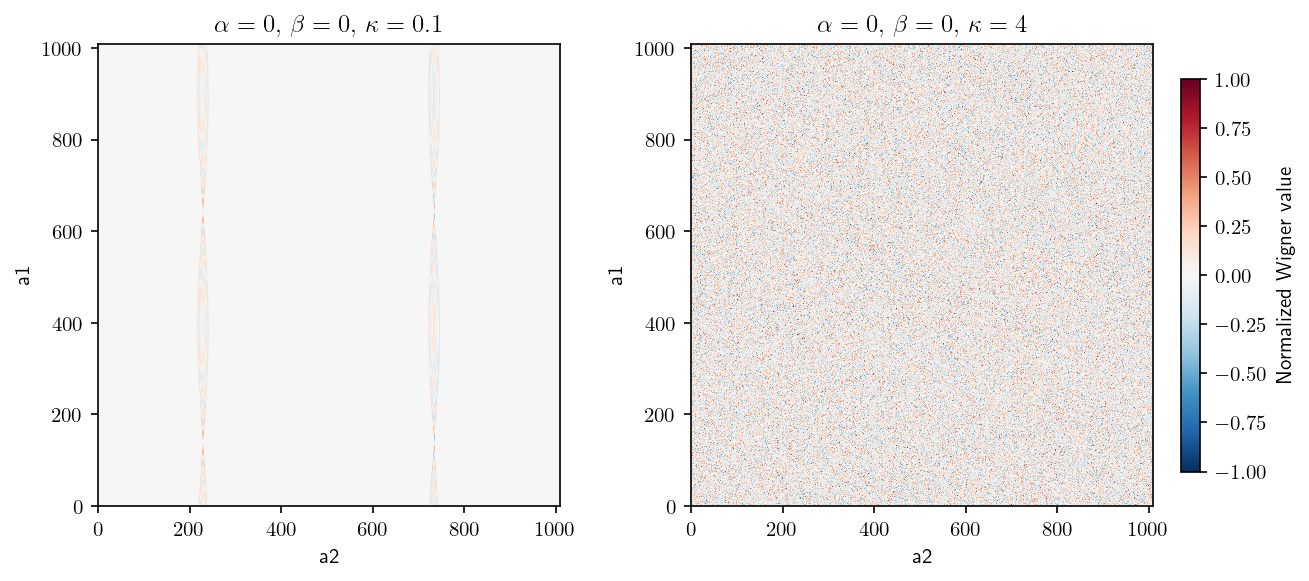

In [32]:
# compute eigenvalues/eigenvectors
eigvals1, eigvecs1 = np.linalg.eig(U)
eigvals2, eigvecs2 = np.linalg.eig(diagonalize_floquet_operator(N, alpha, beta, 4))

# choose two eigenstates
idx1 = N-1
psi1 = eigvecs1[:, idx1]
psi2 = eigvecs2[:, idx1]

# compute Wigner functions
W1 = wigner_function(psi1)
W2 = wigner_function(psi2) * 10

# normalize ONLY for plotting
max_abs = max(np.max(np.abs(W1)), np.max(np.abs(W2)))
W1_norm = W1 / max_abs
W2_norm = W2 / max_abs

# color scale from -1 to 1
norm = colours.TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4),
                         gridspec_kw={'wspace': 0.05})

im1 = axes[0].imshow(W1_norm, cmap='RdBu_r', origin='lower',
                     norm=norm, interpolation='nearest')
axes[0].set_title(r"$\alpha=%g,\,\beta=%g,\,\kappa=%g$" % (alpha, beta, K))
axes[0].set_xlabel("a2")
axes[0].set_ylabel("a1")

im2 = axes[1].imshow(W2_norm, cmap='RdBu_r', origin='lower',
                     norm=norm, interpolation='nearest')
axes[1].set_title(r"$\alpha=%g,\,\beta=%g,\,\kappa=%g$" % (alpha, beta, 4))
axes[1].set_xlabel("a2")
axes[1].set_ylabel("a1")

# shared colorbar
cbar = fig.colorbar(im2, ax=axes, location='right',
                    shrink=0.85, pad=0.02)
cbar.set_label("Normalized Wigner value")

plt.tight_layout()
plt.show()


Level Spacing Statistics

In [4]:
def level_spacing(N, alpha, beta, K, n):
    U = diagonalize_floquet_operator(N, alpha, beta, K)
    eigvals, eigvecs = np.linalg.eig(U)

    #W_floquet_eigvec = wigner_function(eigvecs[:,n])

    omega = np.angle(eigvals)
    omega_sorted = np.sort(omega)

    spacings = np.diff(omega_sorted)
    wrap = (omega_sorted[0] + 2*np.pi) - omega_sorted[-1]
    spacings = np.append(spacings, wrap)

    spacings = np.mod(spacings, 2*np.pi)

    eps = 1e-14
    spacings = spacings[spacings > eps]

    spacings = spacings / np.mean(spacings)

    plt.hist(spacings, density = True, alpha = 0.7, color = 'gray', label = r"$\kappa =$"+f"{K}")

    s = np.linspace(0, 5, 500)
    P_goe = (32/np.pi**2) * s**2 * np.exp(-4*s**2/np.pi)       # GOE / Wigner surmise
    P_poisson = np.exp(-s)
    plt.plot(s, P_goe, 'r-', lw=2, label='GOE (Wigner)')
    plt.plot(s, P_poisson, 'k--', lw=1.5, label='Poisson')

    plt.xlim(0, 5)
    plt.xlabel('Unfolded level statistics')
    plt.ylabel('P(s)')
    plt.legend()
    #plt.title('Nearest-neighbour level spacing (quasienergies)')
    plt.tight_layout()
    plt.show()

    is_symmetric = np.allclose(U, U.T, atol=1e-12)          # U == U^T?

    print("U equals U.T?    ", is_symmetric)

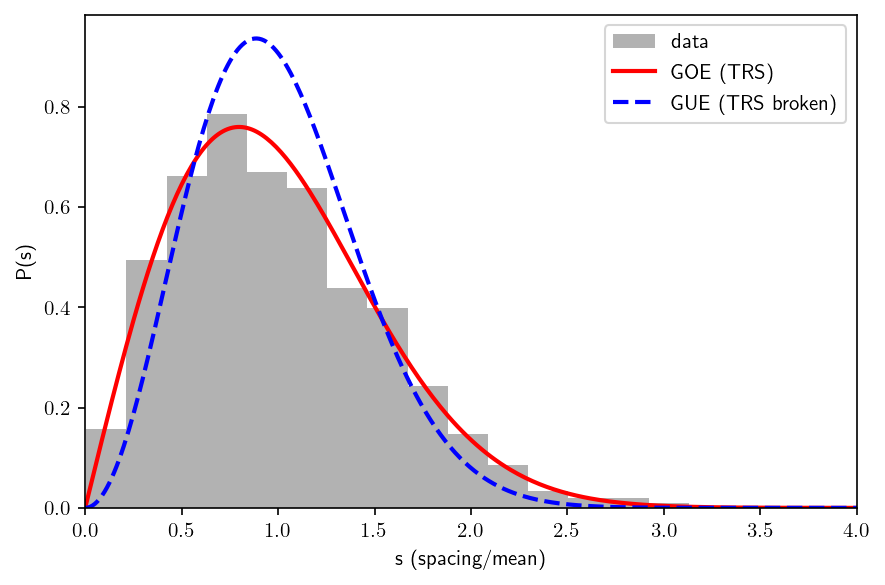

mean r = 0.5351224524057511


In [5]:
U = diagonalize_floquet_operator(N, alpha, 0, 4)

# diagonalize and get phases
eigvals = np.linalg.eigvals(U)
omega = np.sort(np.angle(eigvals))

# circular spacings
s = np.diff(omega)
s = np.append(s, (omega[0] + 2*np.pi) - omega[-1])
s = np.mod(s, 2*np.pi)
s = s[s>1e-14]

# unfold (normalize mean spacing to 1)
s = s / np.mean(s)

# histogram
plt.figure(figsize=(6,4))
plt.hist(s, bins=15, density=True, alpha=0.6, color='gray', label='data')

# Wigner surmises
ss = np.linspace(0,5,400)
P_goe = (np.pi/2)*ss*np.exp(-np.pi*ss**2/4)
P_gue = (32/np.pi**2)*ss**2*np.exp(-4*ss**2/np.pi)
plt.plot(ss, P_goe, 'r-', lw=2, label='GOE (TRS)')
plt.plot(ss, P_gue, 'b--', lw=2, label='GUE (TRS broken)')

plt.xlim(0,4); plt.xlabel('s (spacing/mean)'); plt.ylabel('P(s)')
plt.legend(); plt.tight_layout(); plt.show()

# spacing ratio diagnostic
r = np.minimum(s[1:], s[:-1]) / np.maximum(s[1:], s[:-1])
print("mean r =", np.mean(r))

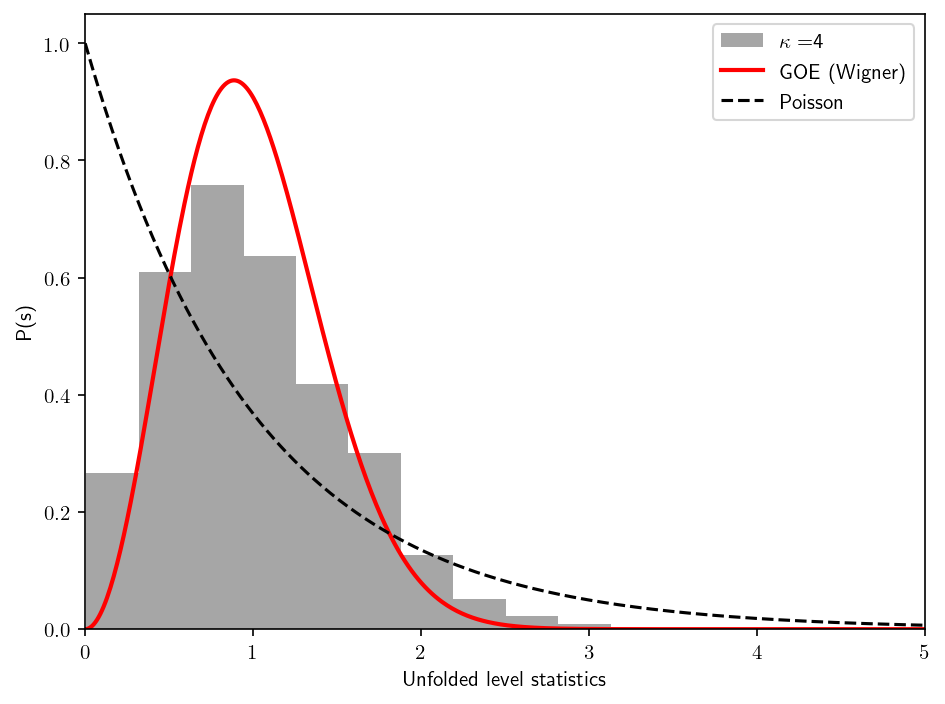

U equals U.T?     False


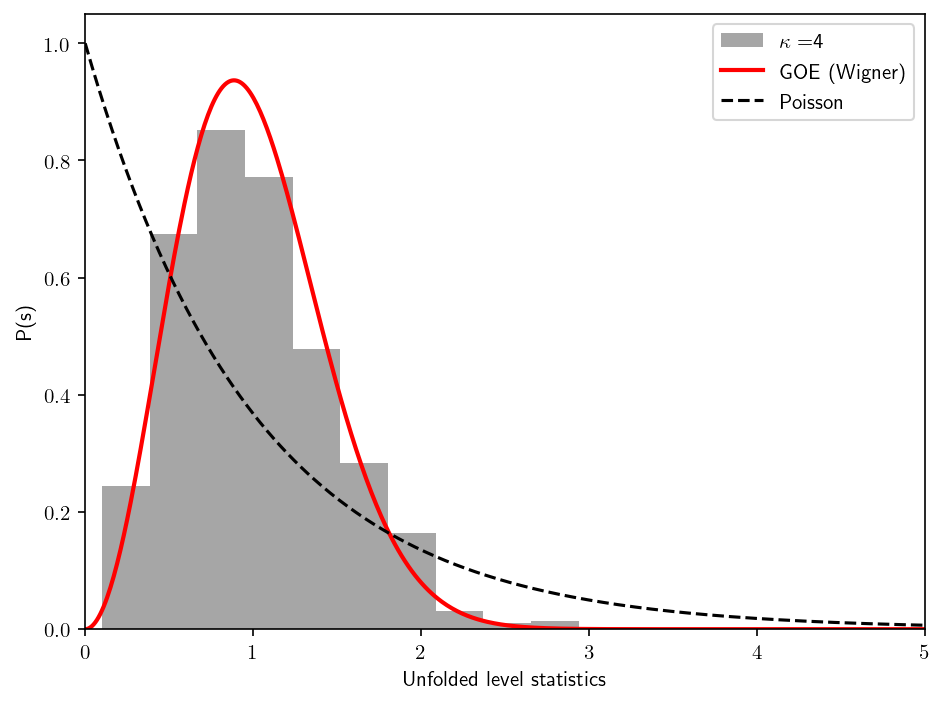

U equals U.T?     False


In [9]:
level_spacing(N, alpha, beta, 4, N-1)
level_spacing(N, alpha, 0.7, 4, N-1)

(beta=0.0, kappa=0.1)  mean r = 0.3798
(beta=0.0, kappa=5.0)  mean r = 0.5117
(beta=0.7, kappa=5.0)  mean r = 0.6125


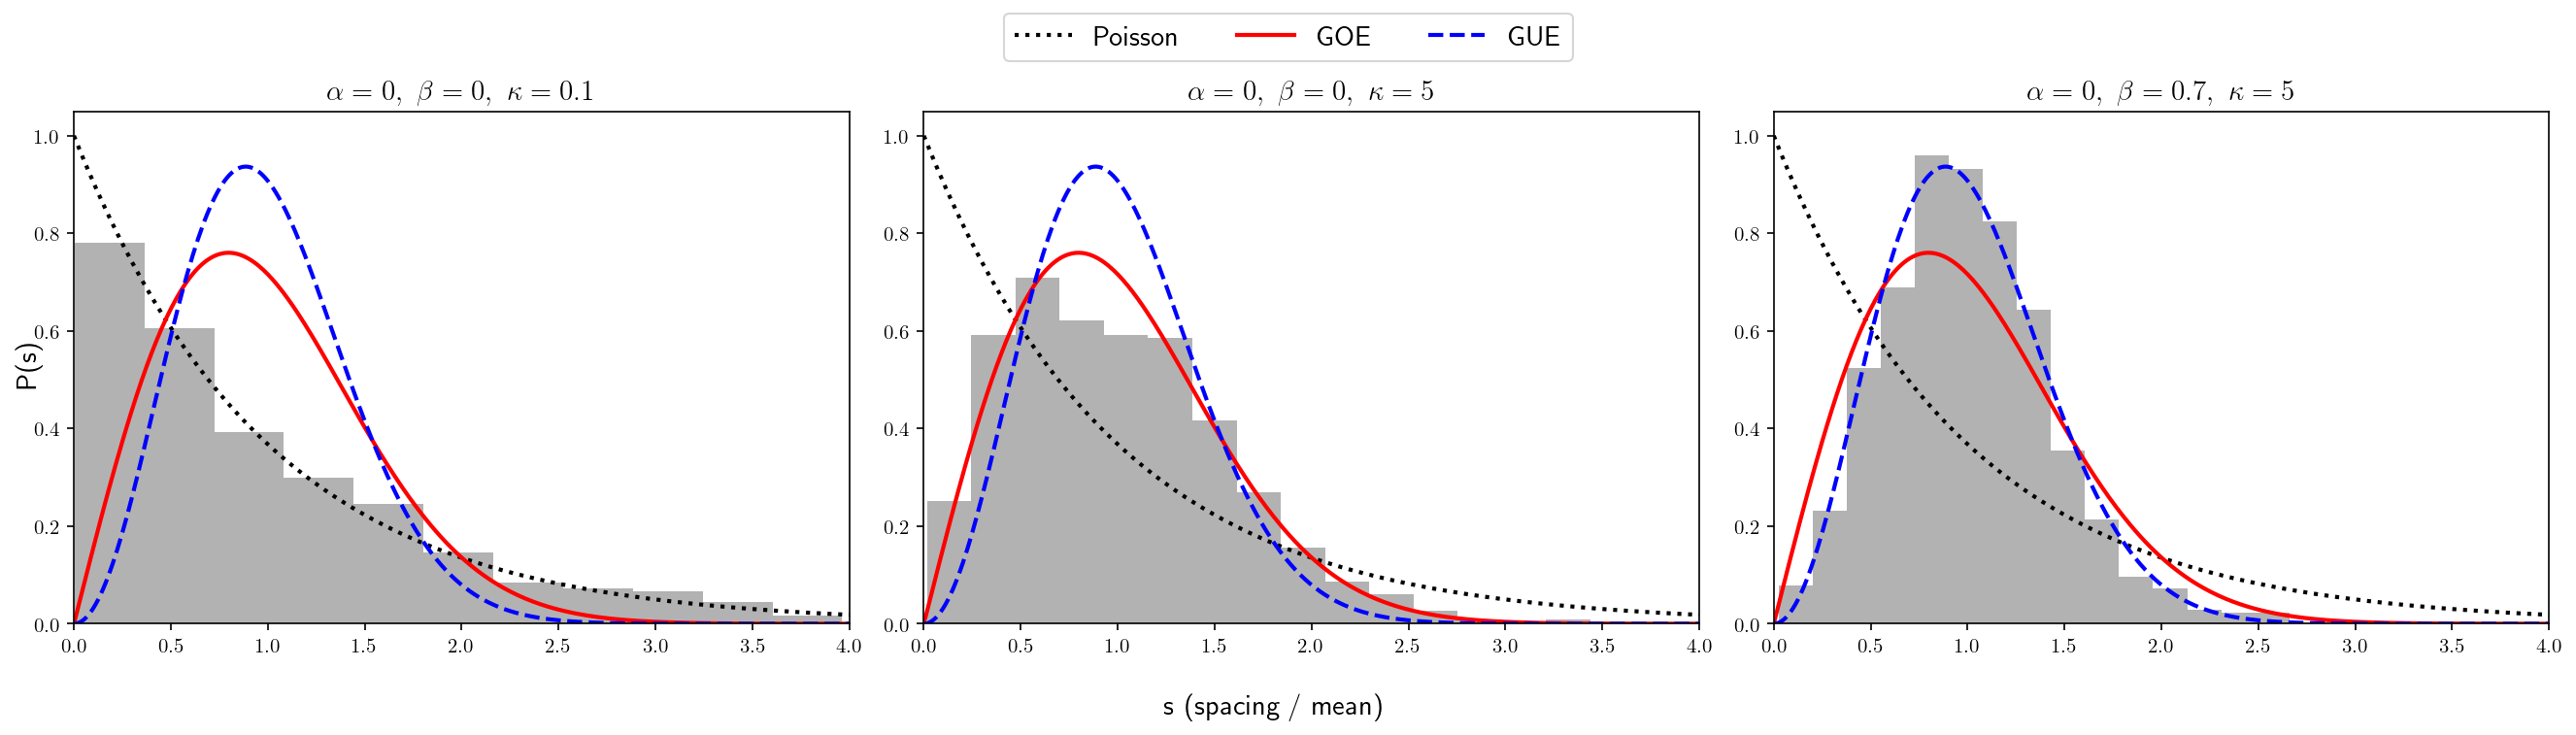

In [38]:
cases = [
    (0,   0.0, 0.1),
    (0,   0.0, 5.0),
    (0,   0.7, 5.0)
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Wigner surmises + Poisson
ss = np.linspace(0, 5, 400)
P_goe = (np.pi/2) * ss * np.exp(-np.pi * ss**2 / 4)
P_gue = (32/np.pi**2) * ss**2 * np.exp(-4 * ss**2 / np.pi)
P_pois = np.exp(-ss)

for ax, (alpha, beta, K) in zip(axes, cases):

    U = diagonalize_floquet_operator(N, alpha, beta, K)
    eigvals = np.linalg.eigvals(U)
    omega = np.sort(np.angle(eigvals))

    s = np.diff(omega)
    s = np.append(s, (omega[0] + 2*np.pi) - omega[-1])
    s = np.mod(s, 2*np.pi)
    s = s[s > 1e-14]

    s = s / np.mean(s)

    ax.hist(s, bins=15, density=True, alpha=0.6, color='gray')

    ax.plot(ss, P_pois, 'k:', lw=2, label='Poisson')
    ax.plot(ss, P_goe, 'r-', lw=2, label='GOE')
    ax.plot(ss, P_gue, 'b--', lw=2, label='GUE')

    ax.set_xlim(0, 4)
    ax.set_title(r"$\alpha=0,\ \beta=%g,\ \kappa=%g$" % (beta, K), fontsize=14)

    r = np.minimum(s[1:], s[:-1]) / np.maximum(s[1:], s[:-1])
    print(f"(beta={beta}, kappa={K})  mean r = {np.mean(r):.4f}")

# --- Shared axis labels for all subplots ---
fig.supxlabel("s (spacing / mean)", fontsize=14)
fig.supylabel("P(s)", fontsize=14)

# --- Shared legend ---
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, fontsize=14)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()


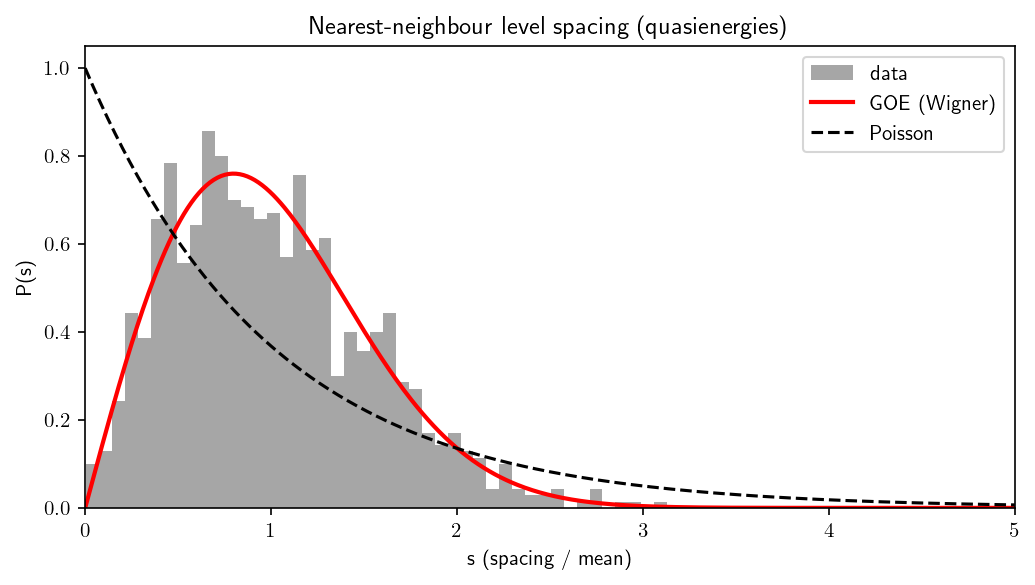

In [7]:
# 1) phases in [-pi,pi)
omega = np.angle(eigvals)

# 2) sort them on the circle
omega_sorted = np.sort(omega)

# 3) nearest-neighbour circular spacings
spacings = np.diff(omega_sorted)
wrap = (omega_sorted[0] + 2*np.pi) - omega_sorted[-1]
spacings = np.append(spacings, wrap)

# ensure positive (numerical safety)
spacings = np.mod(spacings, 2*np.pi)

# 4) reject exact-zero / near-degenerate spacings
eps = 1e-14
spacings = spacings[spacings > eps]

# 5) unfold: normalize mean spacing to 1
spacings = spacings / np.mean(spacings)

# --- Now plot: either histogram (recommended) or scatter
plt.figure(figsize=(7,4))
plt.hist(spacings, bins=45, density=True, alpha=0.7, color='gray', label='data')

# optional: overlay GOE (Wigner) and Poisson for comparison
s = np.linspace(0, 5, 500)
P_goe = (np.pi/2) * s * np.exp(-np.pi*s**2/4)       # GOE / Wigner surmise
P_poisson = np.exp(-s)
plt.plot(s, P_goe, 'r-', lw=2, label='GOE (Wigner)')
plt.plot(s, P_poisson, 'k--', lw=1.5, label='Poisson')

plt.xlim(0, 5)
plt.xlabel('s (spacing / mean)')
plt.ylabel('P(s)')
plt.legend()
plt.title('Nearest-neighbour level spacing (quasienergies)')
plt.tight_layout()
plt.show()

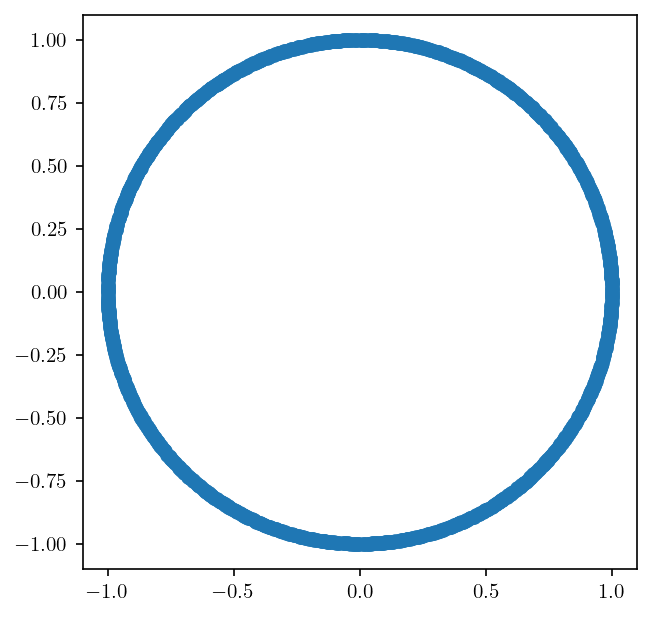

In [8]:
# plot the quasi-energies of the eigenvector

plt.scatter(eigvals.real, eigvals.imag)
plt.gca().set_aspect('equal')
plt.show()